## Mithil Agneya
### 3/1/2026
#### Data analysis and answering questions

#### Importing CSV files and libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("Non-Majors Survey Results - Fall 2024.csv")
df_q1 = pd.read_csv("df_q1.csv")
df_q2 = pd.read_csv("df_q2.csv")
df_q3 = pd.read_csv("df_q3.csv")
df_q4 = pd.read_csv("df_q4.csv")
df_q5 = pd.read_csv("df_q5.csv")

#### Answering Question 1: Which recruitment channel is most effective at reaching students who express a high interest in taking further computing courses?

In [3]:
channels = [col for col in df_q1.columns if 'heard_' in col]

high_interest = {}

for col in channels:
    sub = df_q1[df_q1[col] == 'Yes'] 
    
    if len(sub) > 0:
        high_sub = sub[sub['interest_more_courses'] >= 4]
        per = (len(high_sub) / len(sub)) * 100
    else:
        per = 0 

    label = col.replace('heard_', '').replace('_', ' ').title()
    high_interest[label] = per

results = pd.Series(high_interest).sort_values(ascending=False)
results


Ccm Website        26.315789
Employer           25.000000
Social Media       23.076923
Community Event    18.750000
Current Student    17.391304
Family Friend      14.285714
Billboard          12.500000
High School        12.500000
Alumni             11.538462
Television          0.000000
Radio               0.000000
dtype: float64

#### Shows the actual values of the different percentages of students who replied to each grouping. 

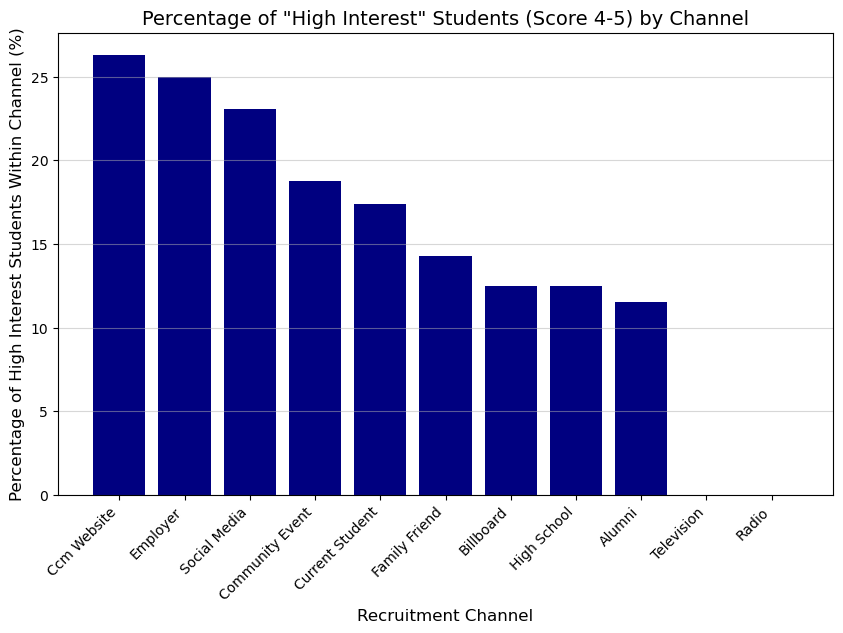

In [4]:
plt.figure(figsize=(10, 6))
plt.bar(results.index, results.values, color='navy')

plt.title('Percentage of "High Interest" Students (Score 4-5) by Channel', fontsize=14)
plt.xlabel('Recruitment Channel', fontsize=12)
plt.ylabel('Percentage of High Interest Students Within Channel (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.5)
plt.show()

#### Analysis: Based on the bar graph, the Social Media recruitment channel was most effective at reaching students who expressed a high interest in taking further computing courses. Around 30% of students recruited by social media indicated a high interest in taking more classes

#### Answering Question 2: What are the primary motivations for taking a computing class among different degree programs?

#### This analysis identifies the primary drivers for non-majors. To improve visual clarity, the top two motivators: "Getting a Computing Job" and "Transferring to a Bachelor's", are highlighted, while secondary reasons are greyed out.

In [9]:
moti_cols = [col for col in df_q2.columns if 'motivation_' in col]

moti_counts = {}
for col in moti_cols:
    count = (df_q2[col] == 'Yes').sum()
    
    clean = col.replace('motivation_', '').replace('_', ' ').title()# Sourced by AI
    moti_counts[clean] = count

results = pd.Series(moti_counts).sort_values(ascending=False)
results


Required Degree        82
Keep Current           70
Professional Dev       65
Career Advancement     54
Personal Enrichment    48
Curiosity              47
Job Displacement       21
Financial              20
Career Change          18
Relocation              9
Certifications          3
dtype: int64

#### Shows actual number of people who replied to each motivator

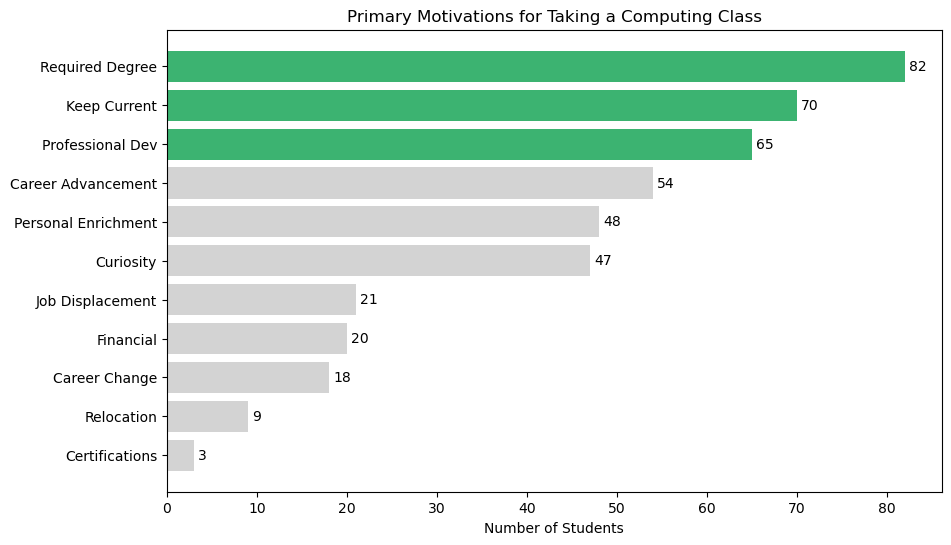

In [17]:
colors = ['mediumseagreen' if val > 60 else 'lightgrey' for val in results.values]

fig, ax = plt.subplots(figsize=(10, 6)) 
bar_plot = ax.barh(results.index, results.values, color=colors)
ax.bar_label(bar_plot, padding=3) 
ax.set_title('Primary Motivations for Taking a Computing Class')
ax.set_xlabel('Number of Students')
ax.invert_yaxis()

plt.show()

#### Analysis: Based on the graph, we can see that the primary motivation for taking a computing class amongst majors apart from computer science is that the course is required for their degree. There are approximately 85 students who replied in this category, with staying up to date and professional development coming in with around 70 and 65 students respectively. 

#### Answering Question 3: Does participation in pre-college outreach programs correlate with higher interest?

#### I compare the average interest scores between students who participated in outreach programs and those who did not. Removing the fixed Y-axis limit allows for a more granular view of the difference between these two groups.

In [41]:
reach_events = []
for col in df_q3:
    if 'prior_event_' in col:
        reach_events.append(col)

df_q3['any_outreach'] = (df_q3[reach_events] == 'Yes').any(axis=1)

comparison = df_q3.groupby('any_outreach')['interest_more_courses'].mean()
 # line of code above splits students by attended outreach or not attended outreach programs and calculates average of the interest column

comparison


any_outreach
False    2.684211
True     2.400000
Name: interest_more_courses, dtype: float64

#### Shows the actual percentage of people who participated in outreach programs(TRUE) and those who did not participate in any outreach programs(FALSE)

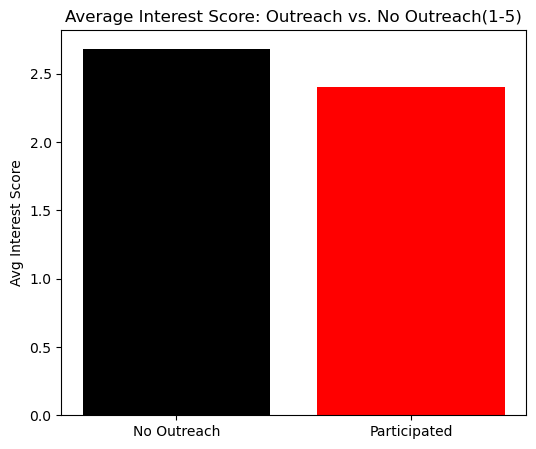

In [39]:
plt.figure(figsize=(6, 5))
plt.bar(['No Outreach', 'Participated'], comparison.values, color=['black', 'red'])
plt.title('Average Interest Score: Outreach vs. No Outreach(1-5)') 
plt.ylabel('Avg Interest Score')
plt.show()

#### Analysis: Interestingly, students who did not participate in the listed outreach programs showed a slightly higher interest in future courses than those who did. This suggests outreach may need to be more focused on the computing department specifically 

#### Answering Question 4: Which computing sub-fields are most popular between different age groups?

#### This plot visualizes topic interest across age groups. The legend is cleaned to remove technical column prefixes for better readability.

In [43]:
interest_topics = []
for col in df_q4:
    if 'course_interest_' in col:
        interest_topics.append(col)
        
age_trends = df_q4.groupby('age')[interest_topics].apply(lambda x: (x == 'Yes').sum()) # Sourced by AI
age_trends.columns = [col.replace('course_interest_', '').replace('_', ' ').title() for col in age_trends.columns]

age_trends

,Web Dev,Cybersecurity,App Dev,Data Analytics,Ml Ai,Programming,Game Design,Hardware
age,,,,,,,,
18 and younger,3,3,5,1,6,3,9,2
19-20,8,14,10,11,9,9,13,10
21-24,5,5,4,3,6,5,2,2
25-34,5,7,5,4,6,5,4,5
35-64,1,2,0,2,1,0,0,3


#### Showing the actual number of people who are interested in each category, grouped by age

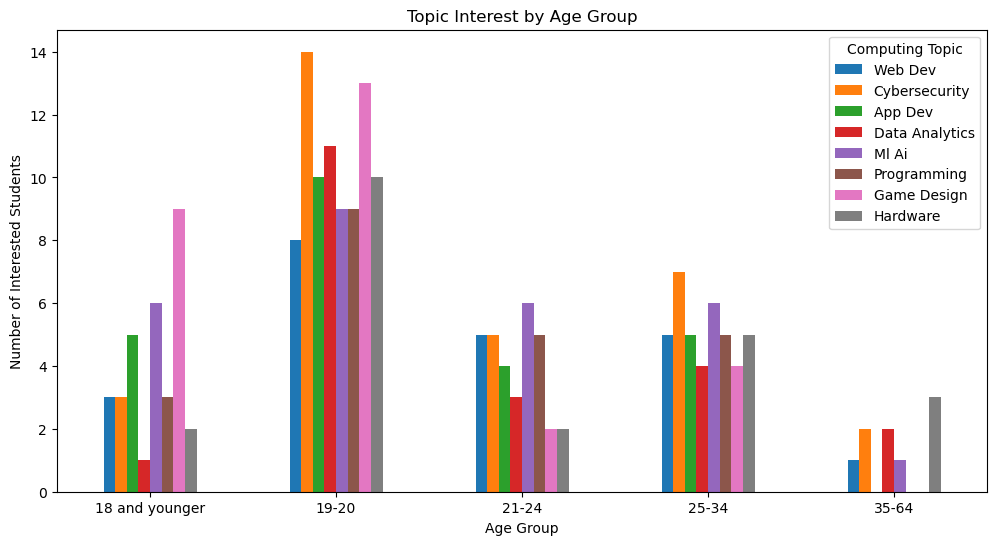

In [42]:
age_trends.plot(kind='bar', figsize=(12, 6))
plt.title('Topic Interest by Age Group')
plt.ylabel('Number of Interested Students')
plt.xlabel('Age Group')
plt.xticks(rotation=0)
plt.legend(title='Computing Topic')
plt.show()

#### Analysis: Game Design is overwhelmingly popular with the "18 and younger" group, whereas Cybersecurity remains a strong interest across almost all age categories. This data can help CCM decide which certifications to prioritize for different age demographics.